# Bank Account Fraud Detection

Organized workflow from data loading and exploration through preprocessing, modeling, tuning, feature engineering, explainability, and model export.


## 1. Setup and Data Loading


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("dataset/Base.csv")

## 2. Initial Data Inspection


In [5]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [6]:
df.shape

(1000000, 32)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [8]:
df.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,4769.781965,4856.324016,184.361849,9.503544,130.989595,0.529886,0.417077,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,1479.212612,919.843934,459.625329,5.033792,69.681812,0.499106,0.493076,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,1300.307314,2825.748405,0.000000,0.000000,-170.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,3593.179135,4268.368423,1.000000,6.000000,83.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,4749.921161,4913.436941,9.000000,9.000000,122.000000,1.000000,0.000000,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,5752.574191,5488.083356,25.000000,13.000000,178.000000,1.000000,1.000000,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,9506.896596,6994.764201,2385.000000,39.000000,389.000000,1.000000,1.000000,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


In [9]:
df.describe(include="object")

,payment_type,employment_status,housing_status,source,device_os
count,1000000,1000000,1000000,1000000,1000000
unique,5,7,7,2,5
top,AB,CA,BC,INTERNET,other
freq,370554,730252,372143,992952,342728


In [10]:
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis


## Target Variable Analysis

The target variable is **fraud_bool**, where:

- **0** = Legitimate Application
- **1** = Fraudulent Application

The dataset is highly imbalanced, with legitimate applications making up the vast majority of records. This imbalance is expected in fraud detection because fraudulent activities are relatively rare.

Because of this, accuracy alone will not be a reliable evaluation metric. Metrics such as Precision, Recall, F1-score, and ROC-AUC will provide a better assessment of model performance.

In [11]:
df["fraud_bool"].value_counts(normalize=True) * 100

fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64

## Encoded Missing Values

Although the dataset contains no standard missing values (`NaN`), several features use **-1** to represent missing or unavailable information.

### Findings

- `prev_address_months_count` contains approximately **71%** of values equal to **-1**, indicating missing or unknown previous address information.
- `bank_months_count` contains approximately **25%** of values equal to **-1**, suggesting unknown or unavailable banking history.
- `session_length_in_minutes` contains a small number of **-1** values (about **0.2%**), likely representing unavailable session duration.
- `current_address_months_count` will be further verified to determine whether encoded missing values exist.

These encoded values will be addressed during the data preprocessing stage.

In [12]:
columns = [
    "prev_address_months_count",
    "current_address_months_count",
    "bank_months_count",
    "session_length_in_minutes"
]

for col in columns:
    print(f"\n{col}")
    print(df[col].value_counts().head())


prev_address_months_count
prev_address_months_count
-1     712920
 11     11475
 28     10275
 29     10150
 10     10082
Name: count, dtype: int64

current_address_months_count
current_address_months_count
6    16376
7    16270
8    16089
5    15896
9    15688
Name: count, dtype: int64

bank_months_count
bank_months_count
-1     253635
 1     194802
 28     80082
 15     59141
 30     50777
Name: count, dtype: int64

session_length_in_minutes
session_length_in_minutes
-1.000000    2015
 4.638723       3
 4.743844       3
 5.256578       3
 4.443948       3
Name: count, dtype: int64


In [13]:
num_cols = [
    "income",
    "customer_age",
    "credit_risk_score",
    "proposed_credit_limit",
    "session_length_in_minutes"
]
cat_cols = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os"
]

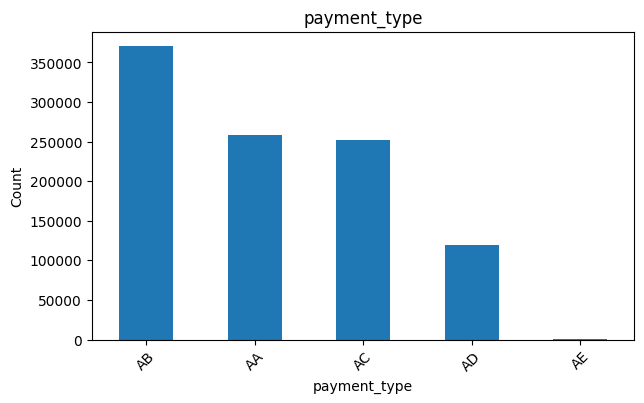

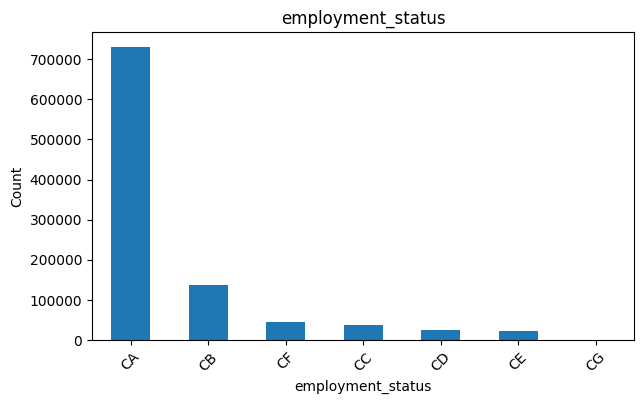

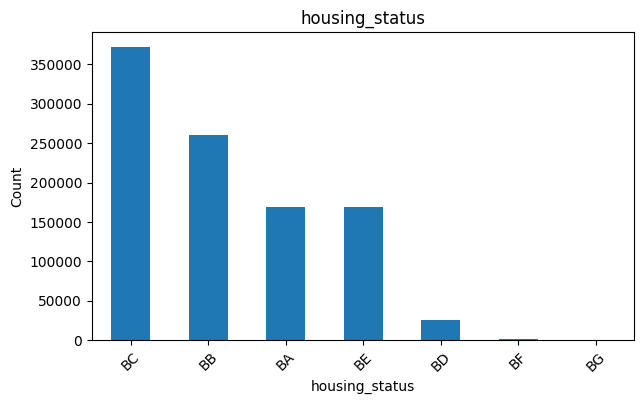

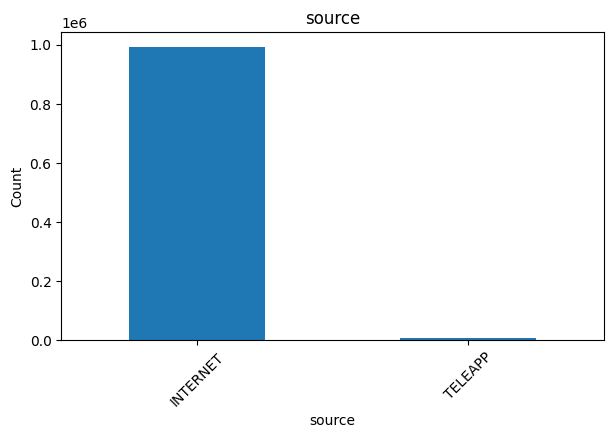

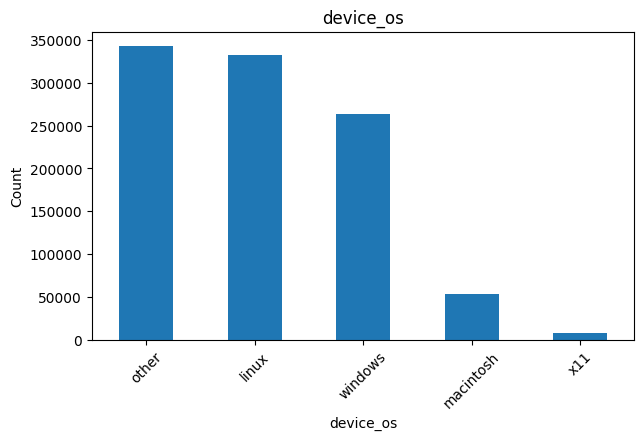

In [14]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    df[col].value_counts().plot(kind="bar")

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

### Fraud Rate by Payment Type

Fraud rates vary across payment methods.

- Payment type AC has the highest fraud rate (~1.67%).
- Payment type AE has the lowest fraud rate (~0.35%).
- This suggests that payment type may be a useful predictive feature.

In [15]:
fraud_payment = pd.crosstab(
    df["payment_type"],
    df["fraud_bool"],
    normalize="index"
) * 100

fraud_payment

fraud_bool,0,1
payment_type,,
AA,99.471828,0.528172
AB,98.874928,1.125072
AC,98.330232,1.669768
AD,98.917845,1.082155
AE,99.653979,0.346021


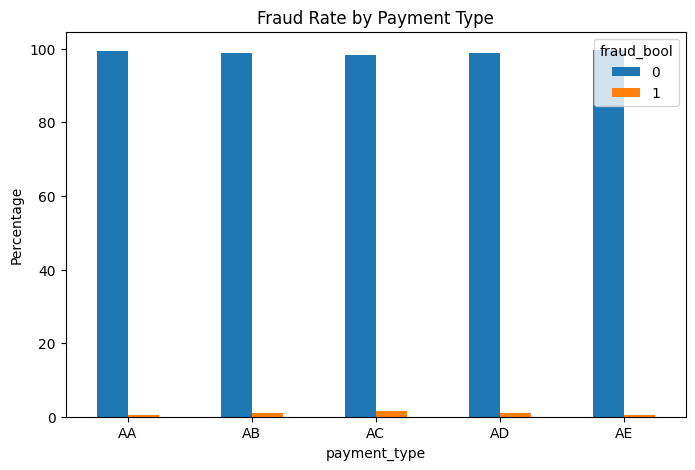

In [16]:
fraud_payment.plot(kind="bar", figsize=(8,5))

plt.title("Fraud Rate by Payment Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Customer Age vs Fraud

Fraud probability increases with customer age.

- Customers aged 10–40 have a fraud rate below 1.5%.
- Fraud increases significantly after age 50.
- Customers aged 90 show the highest fraud rate (over 5%).

This suggests that customer age is an informative predictor for fraud detection.

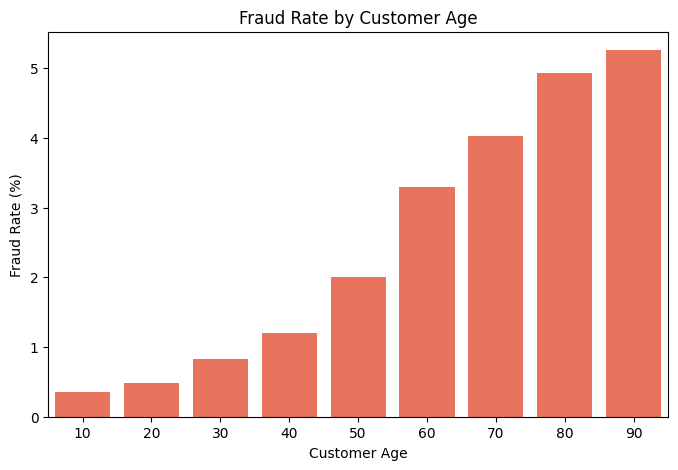

In [17]:
fraud_age = (
    df.groupby("customer_age")["fraud_bool"]
      .mean()
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_age,
            x="customer_age",
            y="fraud_bool",
            color="tomato")

plt.title("Fraud Rate by Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Fraud Rate (%)")
plt.show()

### Credit Risk Score vs Fraud

Fraudulent applications tend to have higher credit risk scores than legitimate ones.

The boxplot shows:

- Fraud cases have a higher median credit risk score.
- Fraudulent transactions are concentrated at higher score ranges.

This indicates that credit risk score is an important feature for fraud prediction.

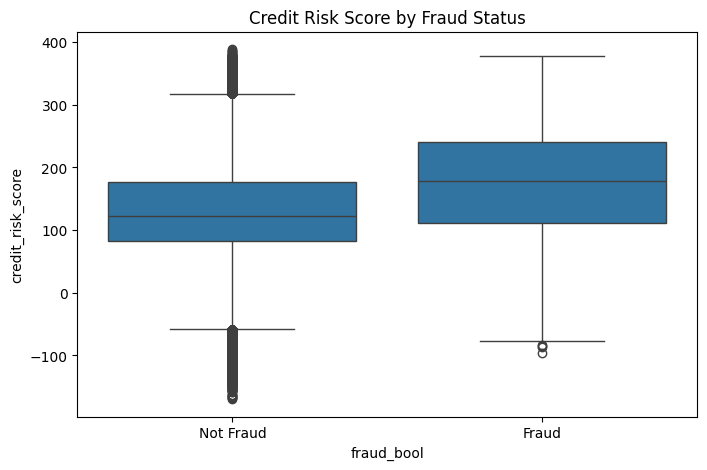

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="fraud_bool",
    y="credit_risk_score"
)

plt.xticks([0,1],["Not Fraud","Fraud"])

plt.title("Credit Risk Score by Fraud Status")

plt.show()

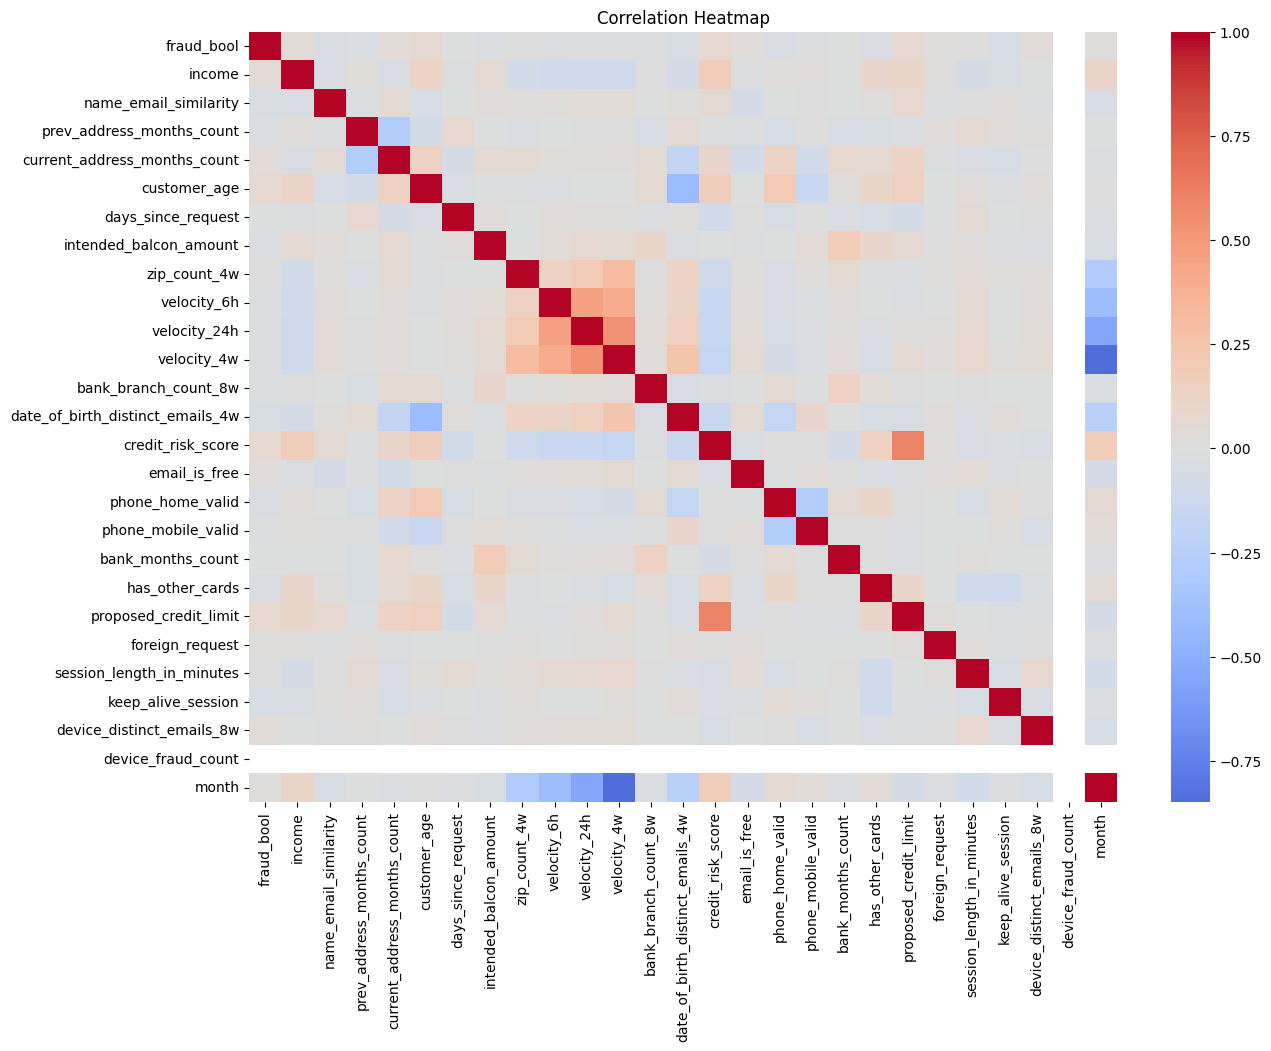

In [19]:

plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## 4. Data Preparation and Preprocessing


## Data Preprocessing

Before training the models, the dataset was prepared using the following steps:

- The target variable (`fraud_bool`) was separated from the input features.
- Categorical variables were converted into numerical format using One-Hot Encoding.
- The dataset was split into 80% training and 20% testing while preserving the fraud ratio using stratified sampling.
- Numerical features were standardized using `StandardScaler` to improve the performance of distance-based and linear models such as Logistic Regression.

In [20]:
X = df.drop("fraud_bool", axis=1)
y = df["fraud_bool"]

In [21]:
categorical_cols = X.select_dtypes(include="object").columns

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [22]:
import joblib

joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(800000, 31)
(200000, 31)
fraud_bool
0    0.988971
1    0.011029
Name: proportion, dtype: float64
fraud_bool
0    0.98897
1    0.01103
Name: proportion, dtype: float64


In [22]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## 5. Baseline Model: Logistic Regression


In [24]:
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
# Predicted labels
y_pred = lr.predict(X_test)

# Predicted probabilities
y_prob = lr.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.78612
Precision: 0.039479658554304395
Recall   : 0.7883046237533998
F1 Score : 0.07519349677865698
ROC AUC  : 0.8642021795050359

Confusion Matrix
[[155485  42309]
 [   467   1739]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    197794
           1       0.04      0.79      0.08      2206

    accuracy                           0.79    200000
   macro avg       0.52      0.79      0.48    200000
weighted avg       0.99      0.79      0.87    200000



In [27]:
# plt.figure(figsize=(6,5))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=["Not Fraud", "Fraud"],
#     yticklabels=["Not Fraud", "Fraud"]
# )

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix - Logistic Regression")
# plt.show()

## Logistic Regression Results

Logistic Regression was trained using `class_weight='balanced'` to address the severe class imbalance in the dataset.

### Performance

- Accuracy: **78.61%**
- Precision: **3.95%**
- Recall: **78.83%**
- F1 Score: **7.52%**
- ROC-AUC: **0.8642**

### Interpretation

The model successfully detected nearly **79% of fraudulent transactions**, resulting in a high recall. However, precision is very low because many legitimate transactions were incorrectly classified as fraud.

This behavior is expected in highly imbalanced fraud detection problems where maximizing fraud detection is often more important than minimizing false alarms.

The ROC-AUC score of **0.8642** indicates that the model has good ability to distinguish between fraudulent and legitimate transactions despite the class imbalance.

Overall, Logistic Regression provides a solid baseline model for comparison with more advanced algorithms.

## 6. Random Forest Modeling and Evaluation


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

Accuracy : 0.988975
Precision: 0.6666666666666666
Recall   : 0.0009066183136899365
F1 Score : 0.0018107741059302852
ROC AUC  : 0.8498805308500172
[[197793      1]
 [  2204      2]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    197794
           1       0.67      0.00      0.00      2206

    accuracy                           0.99    200000
   macro avg       0.83      0.50      0.50    200000
weighted avg       0.99      0.99      0.98    200000



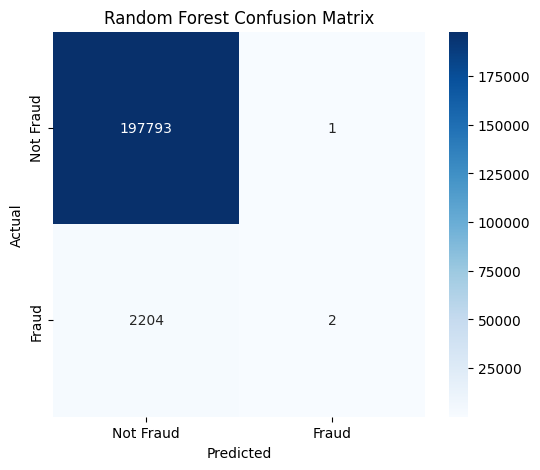

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fraud","Fraud"],
    yticklabels=["Not Fraud","Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [31]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
17,housing_status,0.099355
3,current_address_months_count,0.071818
26,device_os,0.068134
15,credit_risk_score,0.061939
1,name_email_similarity,0.061441
6,intended_balcon_amount,0.048126
8,zip_count_4w,0.041485
5,days_since_request,0.041285
11,velocity_4w,0.041148
9,velocity_6h,0.039979


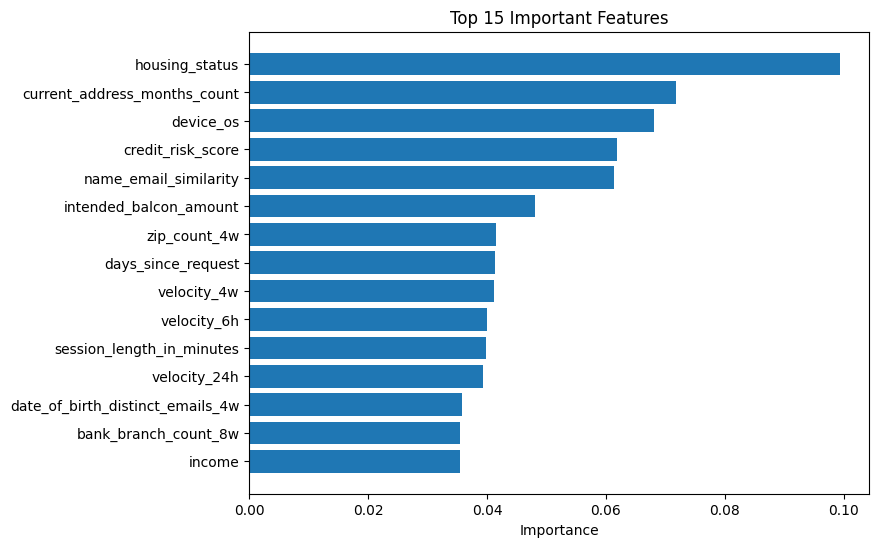

In [32]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"][:15][::-1],
    importance["Importance"][:15][::-1]
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")

plt.show()

In [33]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [34]:
print(y_train.value_counts())

print("\nAfter SMOTE:\n")

print(y_train_smote.value_counts())

fraud_bool
0    791177
1      8823
Name: count, dtype: int64

After SMOTE:

fraud_bool
0    791177
1    791177
Name: count, dtype: int64


In [35]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred = rf_smote.predict(X_test)
y_prob = rf_smote.predict_proba(X_test)[:,1]

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.98837
Precision: 0.3076923076923077
Recall   : 0.043517679057116954
F1 Score : 0.07625099285146943
ROC AUC  : 0.8699099583822067
[[197578    216]
 [  2110     96]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    197794
           1       0.31      0.04      0.08      2206

    accuracy                           0.99    200000
   macro avg       0.65      0.52      0.54    200000
weighted avg       0.98      0.99      0.98    200000



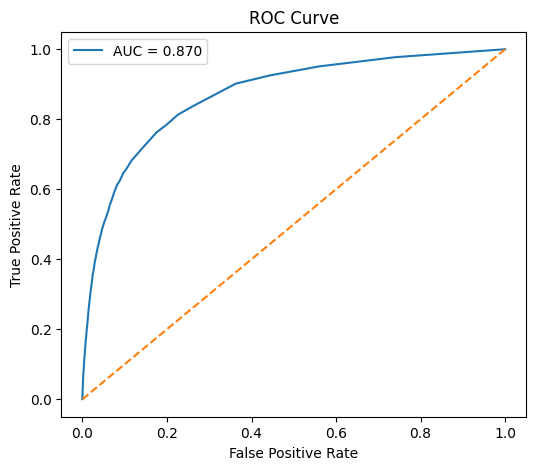

In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

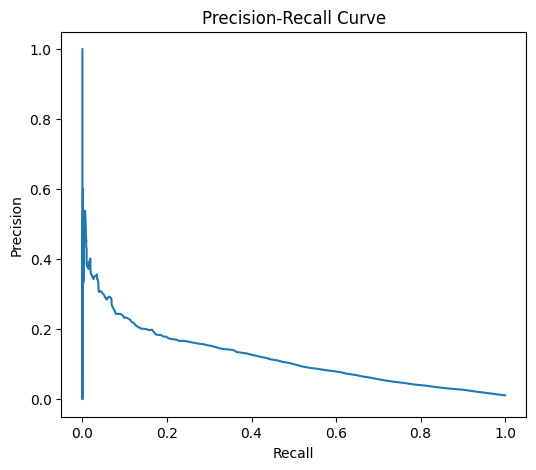

In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [40]:
y_prob = rf.predict_proba(X_test)[:,1]

threshold = 0.20

y_pred = (y_prob >= threshold).astype(int)

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    print(f"\nThreshold = {t}")
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))


Threshold = 0.1
Precision: 0.1749
Recall   : 0.2162
F1 Score : 0.1934

Threshold = 0.2
Precision: 0.2775
Recall   : 0.0675
F1 Score : 0.1086

Threshold = 0.3
Precision: 0.4222
Recall   : 0.0258
F1 Score : 0.0487

Threshold = 0.4
Precision: 0.4324
Recall   : 0.0073
F1 Score : 0.0143

Threshold = 0.5
Precision: 0.6667
Recall   : 0.0009
F1 Score : 0.0018


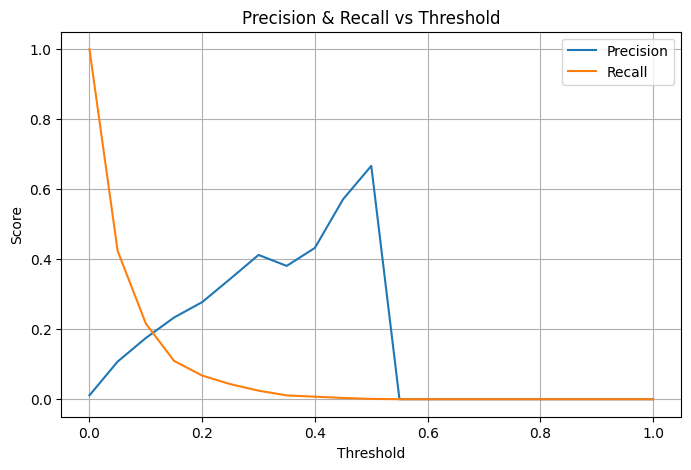

In [42]:
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.0, 1.01, 0.05)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

## 7. Random Forest Hyperparameter Tuning


## Hyperparameter Tuning

To further improve the Random Forest model, **RandomizedSearchCV** was used to search for the optimal combination of hyperparameters. This process evaluates multiple parameter combinations using cross-validation and selects the model with the best performance based on the F1-score.

### Best Hyperparameters

| Parameter | Value |
|-----------|------:|
| Number of Trees (`n_estimators`) | 200 |
| Maximum Depth (`max_depth`) | 20 |
| Minimum Samples Split (`min_samples_split`) | 2 |
| Minimum Samples Leaf (`min_samples_leaf`) | 4 |
| Maximum Features (`max_features`) | sqrt |

### Model Performance

| Metric | Value |
|--------|-------:|
| Accuracy | **97.88%** |
| Precision | **16.31%** |
| Recall | **22.39%** |
| F1-Score | **18.87%** |
| ROC-AUC | **0.875** |

### Confusion Matrix

| | Predicted Normal | Predicted Fraud |
|---|---:|---:|
| **Actual Normal** | 195,259 | 2,535 |
| **Actual Fraud** | 1,712 | 494 |

### Interpretation

The tuned Random Forest model achieved a significant improvement in fraud detection compared to the previous version. Although the overall accuracy decreased slightly, this is expected in highly imbalanced datasets where fraud cases represent only about **1.1%** of all transactions.

More importantly:

- The number of detected fraudulent transactions increased from **96** to **494**, representing more than a **fivefold improvement**.
- The **Recall** increased from **4.35%** to **22.39%**, allowing the model to identify a much larger portion of fraudulent transactions.
- The **F1-score** improved from **0.076** to **0.189**, indicating a better balance between precision and recall.
- The **ROC-AUC** score increased to **0.875**, demonstrating that the model has good ability to distinguish fraudulent from legitimate transactions.

These results show that hyperparameter tuning substantially enhanced the model's effectiveness for fraud detection, making it a stronger candidate for deployment than the default Random Forest model.

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [44]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [45]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [46]:
random_search.fit(X_train, y_train) 
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}


In [47]:
best_rf = random_search.best_estimator_

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.978765
Precision: 0.1630901287553648
Recall   : 0.22393472348141433
F1 Score : 0.18872970391595034
ROC AUC  : 0.8747352002927742
[[195259   2535]
 [  1712    494]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    197794
           1       0.16      0.22      0.19      2206

    accuracy                           0.98    200000
   macro avg       0.58      0.61      0.59    200000
weighted avg       0.98      0.98      0.98    200000



## 8. XGBoost Modeling


In [49]:
from xgboost import XGBClassifier
fraud = y_train.sum()
normal = len(y_train) - fraud

print("Fraud:", fraud)
print("Normal:", normal)

scale_pos_weight = normal / fraud
print(scale_pos_weight)

Fraud: 8823
Normal: 791177
89.67210699308625


In [50]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# XGBoost predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.882025
Precision: 0.06386362709514294
Recall   : 0.7098821396192203
F1 Score : 0.11718486923335952
ROC AUC  : 0.8909549449649947
[[174839  22955]
 [   640   1566]]
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    197794
           1       0.06      0.71      0.12      2206

    accuracy                           0.88    200000
   macro avg       0.53      0.80      0.53    200000
weighted avg       0.99      0.88      0.93    200000



In [52]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
17,housing_status,0.139446
26,device_os,0.095391
21,has_other_cards,0.083827
27,keep_alive_session,0.078354
18,phone_home_valid,0.072128
16,email_is_free,0.050470
28,device_distinct_emails_8w,0.040232
2,prev_address_months_count,0.035910
0,income,0.035661
22,proposed_credit_limit,0.026685


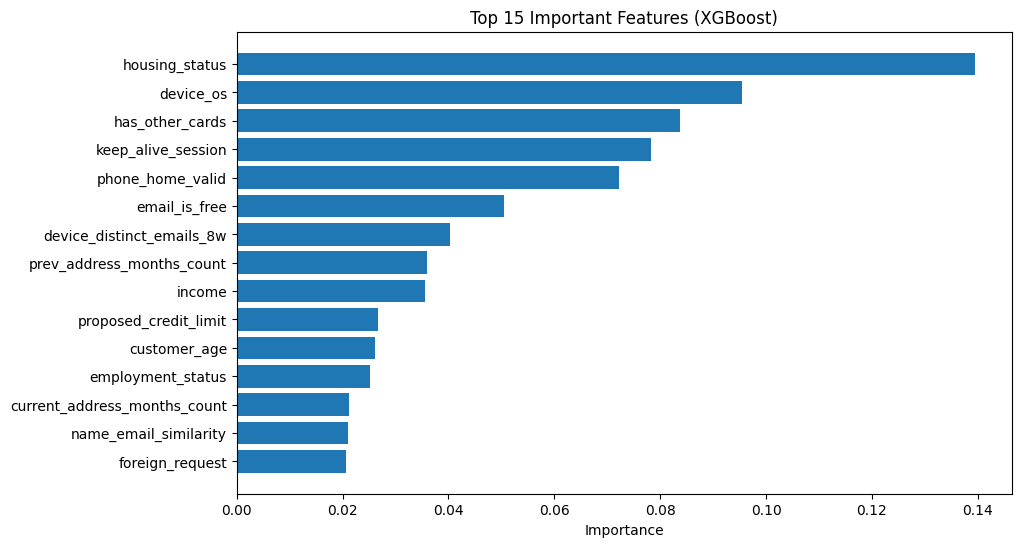

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 15 Important Features (XGBoost)")

plt.show()

## 9. Feature Engineering and Model Retraining


**FEATURE ENGNEERING**

In [54]:
df["velocity_ratio"] = df["velocity_6h"] / (df["velocity_24h"] + 1)
df["address_difference"] = (
    df["current_address_months_count"]
    - df["prev_address_months_count"]
)
df["valid_contact"] = (
    df["phone_home_valid"]
    + df["phone_mobile_valid"]
)
df["high_velocity"] = (
    df["velocity_6h"] > df["velocity_6h"].quantile(0.95)
).astype(int)
df["high_credit_limit"] = (
    df["proposed_credit_limit"] >= 1000
).astype(int)
df["young_customer"] = (
    df["customer_age"] <= 25
).astype(int)
df["new_bank_customer"] = (
    df["bank_months_count"] <= 1
).astype(int)
df["new_address"] = (
    df["current_address_months_count"] <= 6
).astype(int)


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.78612
Precision: 0.039479658554304395
Recall   : 0.7883046237533998
F1 Score : 0.07519349677865698
ROC AUC  : 0.8642021795050359
[[155485  42309]
 [   467   1739]]
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    197794
           1       0.04      0.79      0.08      2206

    accuracy                           0.79    200000
   macro avg       0.52      0.79      0.48    200000
weighted avg       0.99      0.79      0.87    200000



In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.988985
Precision: 0.8
Recall   : 0.001813236627379873
F1 Score : 0.003618272274988693
ROC AUC  : 0.8321529214287076
[[197793      1]
 [  2202      4]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    197794
           1       0.80      0.00      0.00      2206

    accuracy                           0.99    200000
   macro avg       0.89      0.50      0.50    200000
weighted avg       0.99      0.99      0.98    200000



In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred = rf_smote.predict(X_test)
y_prob = rf_smote.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.9883
Precision: 0.2932098765432099
Recall   : 0.04306436990027199
F1 Score : 0.07509881422924901
ROC AUC  : 0.8593612534927522
[[197565    229]
 [  2111     95]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    197794
           1       0.29      0.04      0.08      2206

    accuracy                           0.99    200000
   macro avg       0.64      0.52      0.53    200000
weighted avg       0.98      0.99      0.98    200000



In [58]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":[100,200,300],
    "max_depth":[10,20,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2"]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

random_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}


In [59]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.978765
Precision: 0.1630901287553648
Recall   : 0.22393472348141433
F1 Score : 0.18872970391595034
ROC AUC  : 0.8747352002927742
[[195259   2535]
 [  1712    494]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    197794
           1       0.16      0.22      0.19      2206

    accuracy                           0.98    200000
   macro avg       0.58      0.61      0.59    200000
weighted avg       0.98      0.98      0.98    200000



In [60]:
from xgboost import XGBClassifier

fraud = y_train.sum()
normal = len(y_train) - fraud

scale_pos_weight = normal / fraud

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [61]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.882025
Precision: 0.06386362709514294
Recall   : 0.7098821396192203
F1 Score : 0.11718486923335952
ROC AUC  : 0.8909549449649947
[[174839  22955]
 [   640   1566]]
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    197794
           1       0.06      0.71      0.12      2206

    accuracy                           0.88    200000
   macro avg       0.53      0.80      0.53    200000
weighted avg       0.99      0.88      0.93    200000



In [62]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
17,housing_status,0.112642
26,device_os,0.075375
3,current_address_months_count,0.070467
15,credit_risk_score,0.061998
1,name_email_similarity,0.060061
6,intended_balcon_amount,0.046396
5,days_since_request,0.038763
11,velocity_4w,0.038499
8,zip_count_4w,0.037871
25,session_length_in_minutes,0.036447


In [63]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
17,housing_status,0.139446
26,device_os,0.095391
21,has_other_cards,0.083827
27,keep_alive_session,0.078354
18,phone_home_valid,0.072128
16,email_is_free,0.050470
28,device_distinct_emails_8w,0.040232
2,prev_address_months_count,0.035910
0,income,0.035661
22,proposed_credit_limit,0.026685


## 10. Advanced Boosting and Tuning


In [64]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
fraud = y_train.sum()
normal = len(y_train) - fraud

scale_pos_weight = normal / fraud

print(scale_pos_weight)

89.67210699308625


In [65]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

In [66]:
param_dist = {

    "n_estimators":[100,200,300,500],

    "max_depth":[3,5,7,9],

    "learning_rate":[0.01,0.05,0.1,0.2],

    "subsample":[0.6,0.8,1.0],

    "colsample_bytree":[0.6,0.8,1.0],

    "min_child_weight":[1,3,5],

    "gamma":[0,0.1,0.3,0.5]

}

In [67]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_dist,

    n_iter=20,

    scoring="roc_auc",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [68]:
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [69]:
print(random_search.best_params_)

{'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [70]:
best_xgb = random_search.best_estimator_

In [71]:
from sklearn.metrics import *

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.829455
Precision: 0.04996473409507688
Recall   : 0.8028105167724388
F1 Score : 0.09407452657299939
ROC AUC  : 0.8973247620712488
[[164120  33674]
 [   435   1771]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91    197794
           1       0.05      0.80      0.09      2206

    accuracy                           0.83    200000
   macro avg       0.52      0.82      0.50    200000
weighted avg       0.99      0.83      0.90    200000



In [72]:
from lightgbm import LGBMClassifier
fraud = y_train.sum()
normal = len(y_train) - fraud

scale_pos_weight = normal / fraud

In [73]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 8823, number of negative: 791177
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.072233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3227
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496160
[LightGBM] [Info] Start training from score -4.496160


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [74]:
from sklearn.metrics import *

y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.837305
Precision: 0.05148602691113411
Recall   : 0.7892112420670897
F1 Score : 0.09666583381916105
ROC AUC  : 0.8929230986227774
[[165720  32074]
 [   465   1741]]
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    197794
           1       0.05      0.79      0.10      2206

    accuracy                           0.84    200000
   macro avg       0.52      0.81      0.50    200000
weighted avg       0.99      0.84      0.90    200000



In [75]:
from xgboost import XGBClassifier

fraud = y_train.sum()
normal = len(y_train) - fraud

scale_pos_weight = normal / fraud

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    gamma=0.1,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [76]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(xgb)

print("Model is fitted!")

Model is fitted!


In [77]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

## 11. Model Explainability


In [78]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

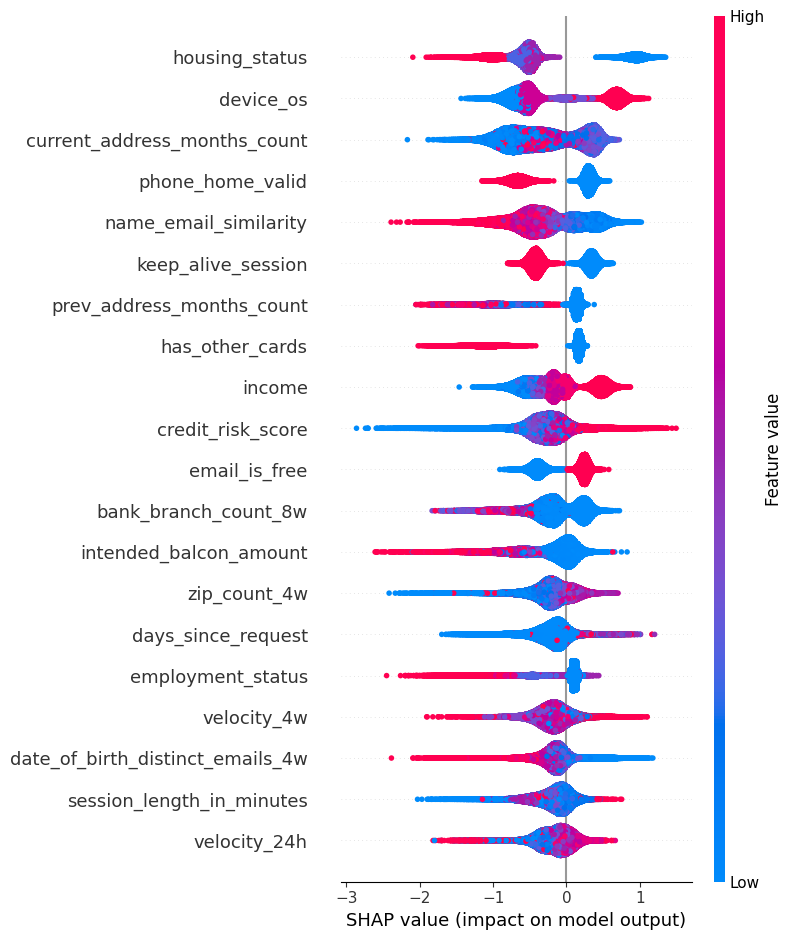

In [79]:
shap.summary_plot(shap_values, X_test)

## 12. Model Export


In [82]:
import joblib

joblib.dump(best_xgb, "best_xgb_model.pkl")

['best_xgb_model.pkl']

In [83]:
import os

print(os.getcwd())

c:\Users\Asus\OneDrive\Desktop\ML_WORK\Bank-Account-Fraud-Detection


In [84]:
import os

print(os.listdir())

['.gitignore', 'app.py', 'Bank_Account_Fraud_Detection.ipynb', 'best_xgb_model.pkl', 'dataset', 'LICENSE', 'README.md', 'requirements.txt']
